# 🦟 Malaria Cell Classification With PyTorch

## Medical AI Project For AltayBioAI

This Project Demonstrates A Lightweight Convolutional Neural Network (CNN) For Malaria Cell Classification Using PyTorch.

The Goal Is To Classify Microscopic Blood Cell Images Into Two Categories:

* Parasitized
* Uninfected

The Project Is Designed To Be Lightweight, Educational, And Easy To Reproduce On Google Colab And Consumer Hardware.

---

## 📚 Dataset

Dataset: Cell Images For Detecting Malaria

The Dataset Contains Microscopic Images Of Red Blood Cells Collected For Malaria Detection Research.

Classes:

* Parasitized
* Uninfected

---

## 🧠 Technologies Used

* PyTorch
* Torchvision
* KaggleHub
* NumPy
* Matplotlib
* Google Colab

---

## 🎯 Project Objectives

* Learn Medical Image Classification
* Build A Lightweight CNN Model
* Explore Biomedical AI Applications
* Practice Deep Learning With PyTorch
* Create Reproducible Medical AI Experiments

---

## ⚡ Training Note

The Default Number Of Epochs Is Intentionally Kept Low To Reduce Training Time And Make The Notebook Accessible For Google Colab And CPU Users.

Increasing The Number Of Epochs May Improve The Final Model Performance And Classification Accuracy.

---

## ⚠️ Disclaimer

This Project Is Intended For Educational And Research Purposes Only.

The Model Is Not Intended For Clinical Diagnosis Or Medical Decision-Making.


Installing KaggleHub:

In [19]:
!pip install -q kagglehub

Importing Libraries:

In [37]:
import kagglehub
import os
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from google.colab import files
import matplotlib.pyplot as plt

Download Dataset & Suggested Dataset: iarunava/cell-images-for-detecting-malaria

In [21]:
path = kagglehub.dataset_download(
    "iarunava/cell-images-for-detecting-malaria"
)

print(path)

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
/kaggle/input/cell-images-for-detecting-malaria


Transform:

In [22]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

Loading Dataset:

In [23]:
dataset_path = os.path.join(
    path,
    "cell_images"
)

dataset = ImageFolder(
    dataset_path,
    transform=transform
)

Train & Validation:

In [24]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

DataLoader:

In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
)

Lightweight CNN Model:

In [30]:
class MalariaCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)

        return x

Device:

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get the number of classes from the dataset
num_classes = len(dataset.classes)

model = MalariaCNN(num_classes=num_classes).to(device)

Loss & Optimizer:

In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

Model Training:

Training Note:
This Notebook Uses 2 Epochs By Default To Keep Training Time Short
And Make The Project Accessible On Google Colab And CPU Systems.
Users Are Encouraged To Increase The Number Of Epochs For Better Results.

In [34]:
epochs = 2

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss:.4f}"
    )

Epoch 1: 1052.4669
Epoch 2: 1047.6318


Save & Download Model:

In [35]:
torch.save(
    model.state_dict(),
    "malaria_cnn.pth"
)

print("Model Saved Successfully!")

files.download(
    "malaria_cnn.pth"
)

Model Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculating Accuracy:

Note: This Model Was Trained For Only 2 Epochs. For Better Accuracy, Increase The Number Of Epochs According To Your Hardware.

In [36]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 48.94%


Show A Few Predictions:

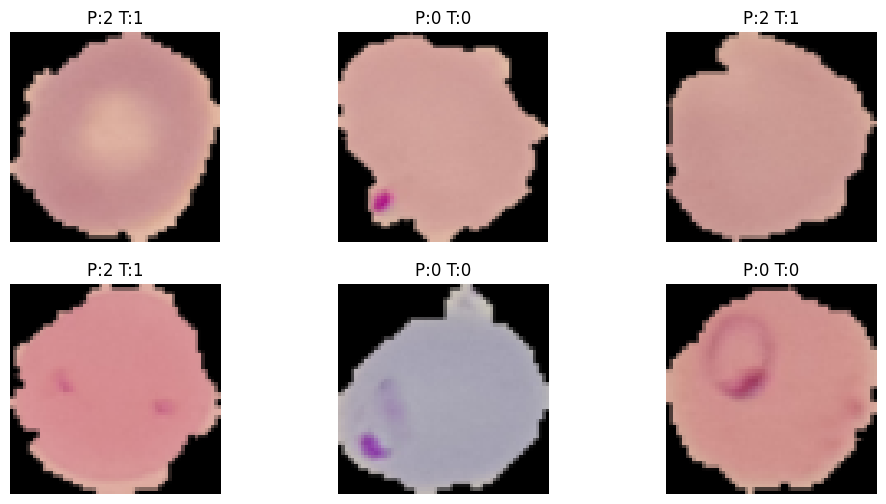

In [38]:
images, labels = next(iter(val_loader))
images = images.to(device)
model.eval()

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].cpu().permute(1,2,0)
    plt.imshow(img)
    plt.title(
        f"P:{preds[i].item()} T:{labels[i].item()}"
    )

    plt.axis("off")

plt.show()